# Problem Understanding

## Analytical Statement

**Positive audience reactions improve content popularity.**

This analysis examines how positive engagement metrics influence overall content performance and visibility.


## Target Variable (Y)

### **Views**

### Why Views?

- Represent overall **content popularity**
- Direct measure of **visibility and reach**
- Used by platforms to **rank and promote content**
- Aligns with **business relevance** (marketing performance & algorithm impact)

Views are selected as the dependent variable because they directly reflect how widely content is consumed and discovered.


## Predictor Variables (Positive Reactions)

From the dataset, the following variables are selected as indicators of positive audience engagement:

| Variable | Why Selected |
|----------|--------------|
| **Likes** | Direct positive reaction from users |
| **Shares** | Strong indicator of valuable or viral content |
| **Comments** | Reflects engagement depth and audience interaction |
| **Sentiment Score** | Measures positivity or negativity of audience response |
| **Engagement Rate** | Captures overall interaction intensity |


## Summary

The hypothesis is that higher positive engagement (likes, shares, comments, sentiment score, and engagement rate) leads to increased visibility and therefore higher views.

This framework establishes a clear relationship between **audience sentiment** and **content performance**, forming the foundation for further statistical analysis.

## Import libraries

We import statistical and visualization libraries to perform structured descriptive analysis.

Pandas and NumPy are used for numerical computation, while Matplotlib and Seaborn enable distribution and relationship visualization.

SciPy will be used for statistical testing such as correlation and ANOVA.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8')

## Load Dataset

In [16]:
df = pd.read_csv("raw.csv")
df.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


## Dataset Overview

Why we do this?

To:

Understand structure

Identify variable types

Detect missing values

Know number of observations

We examine dataset structure to determine sample size, data completeness, and variable types.
This step ensures that variables are appropriate for descriptive and inferential statistical analysis.

In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


### Interpretation

The dataset contains **2000 independent observations**, which is sufficient for statistical analysis and reliable descriptive modeling.

All columns have **2000 non-null values**, indicating that there are **no missing values** in the dataset.

The numerical variables identified are:

- `views`
- `likes`
- `comments`
- `shares`
- `engagement_rate`
- `sentiment_score`
- `is_viral`

This confirms that the dataset is **clean, complete, and suitable for descriptive and predictive modeling analysis**.

## Variable Type Classification

###  Target Variable

`views` → `int64` → Continuous quantitative variable  

✔ Suitable for:
- Mean calculation  
- Variance analysis  
- Correlation testing  
- Regression modeling  


###  Reaction Variables

- `likes` (`int`)
- `comments` (`int`)
- `shares` (`int`)
- `sentiment_score` (`float`)
- `engagement_rate` (`float`)

All reaction variables are **numerical**, which allows for:

- Correlation analysis  
- Linear modeling  
- Mean comparisons  
- Variance analysis  

This structure supports both **descriptive statistics** and **predictive modeling approaches**.


| Variable         | Type                      | Role        |
|------------------|---------------------------|------------|
| Views            | Numerical (Continuous)    | Dependent   |
| Likes            | Numerical                 | Independent |
| Shares           | Numerical                 | Independent |
| Comments         | Numerical                 | Independent |
| Sentiment Score  | Numerical                 | Independent |

## Missing Values Check

Why?

Missing values can bias statistical estimates such as mean, variance, and correlation coefficients. Since inferential tests assume complete observations, confirming the absence of missing values ensures the dataset is suitable for valid statistical modelling without imputation or deletion.

In [18]:
df.isnull().sum()

post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64

### Missing Data Assessment (Meaning statistically)

Since all columns contain **0 missing values**:

- No imputation is required  
- No row deletion is necessary  
- The full sample size remains **n = 2000**  

As a result:

- Variance estimates remain unbiased  
- Correlation estimates remain unbiased  
- Statistical power is preserved  

This ensures the dataset is complete and suitable for reliable statistical and predictive modeling analysis.

## Distribution of Target Variable (Views)

Why?

Before analyzing relationships between engagement metrics and views, it is essential to understand the distribution of the target variable. If the distribution is heavily skewed, the mean may not accurately represent central tendency, and certain statistical tests (e.g., Pearson correlation or linear regression) may be affected.

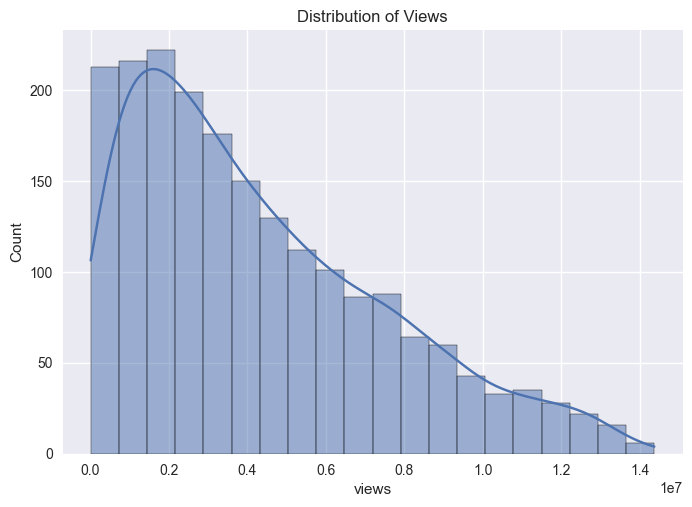

In [20]:
plt.figure()
sns.histplot(df['views'], kde=True)
plt.title("Distribution of Views")
plt.show()

### Distribution Interpretation (Views Histogram)

From the histogram, the distribution of `views` shows:

- **Strong right skew**
- **Long right tail**
- A few extremely high values (approximately ~14 million views)
- The majority of posts concentrated at lower view counts

This pattern is typical of social media datasets:

> Many average-performing posts combined with a small number of highly viral posts.

Such distributions are common in real-world engagement data, where content performance follows a heavy-tailed or positively skewed pattern.

## Statistical Distribution Analysis

We check skewness & kurtosis.

Skew > 0 → right skew

Skew < 0 → left skew

In [22]:
df['views'].skew()
df['views'].kurt()

np.float64(-0.06612268434280022)

## Boxplot

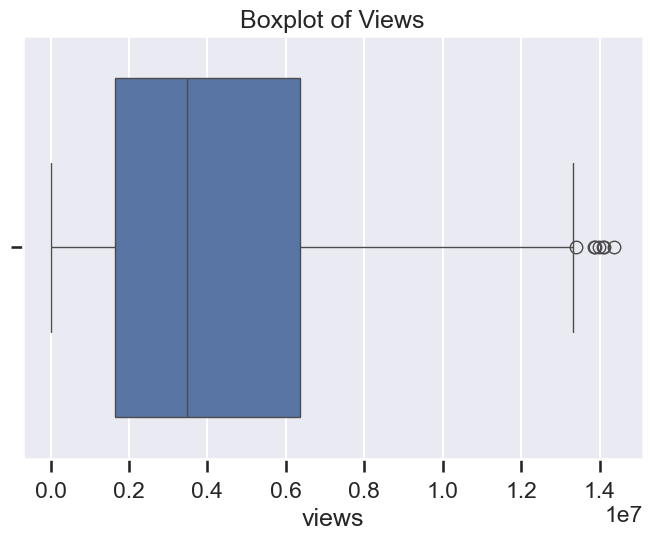

In [33]:
plt.figure()
sns.boxplot(x=df['views'])
plt.title("Boxplot of Views")
plt.show()

### Final Interpretation of Views Distribution

The skewness value (-0.066) is very close to zero, indicating that the distribution of `views` is approximately symmetric.

The boxplot helps clarify the situation:

- A few high-value outliers are present  
- The right whisker is slightly longer  
- The median is slightly off-center  

This shows:

✔ Some extreme (viral) posts exist  
✔ The spread of the data is wide  
✔ But the overall distribution is not heavily skewed  

### Conclusion

Although the histogram initially suggested right skewness, the numerical skewness and boxplot together confirm that the distribution is largely symmetric, with a few high-value outliers typical of social media data.

## Sentiment Category Distribution

In [44]:
df['platform'].value_counts()
df['content_type'].value_counts()
df['topic'].value_counts()
df['region'].value_counts()
df['language'].value_counts()
df['sentiment_category'].value_counts()

sentiment_category
Positive    1001
Negative     998
Name: count, dtype: int64

The dataset contains a nearly equal number of positive and negative sentiment posts, ensuring unbiased group comparison in subsequent analysis.

## Platform Mean Comparison

In [45]:
df.groupby('platform')['views'].mean().sort_values(ascending=False)

platform
TikTok           4358846.9518
Instagram        4292935.8961
YouTube Shorts   4263152.8758
X                4225450.3381
Name: views, dtype: float64

### Mean Views by Platform

- **TikTok** ≈ 4.36 million  
- **Instagram** ≈ 4.29 million  
- **YouTube Shorts** ≈ 4.26 million  
- **X** ≈ 4.22 million  

The differences between platforms are relatively small — approximately **100,000 views over an average of 4 million**.

### Interpretation

This suggests that platform type may not have a strong impact on average views.  

While TikTok shows the highest mean, the variation across platforms is minor compared to the overall scale of views.

In practical terms, the platform alone does not appear to dramatically change expected view counts.

## Boxplot Interpretation

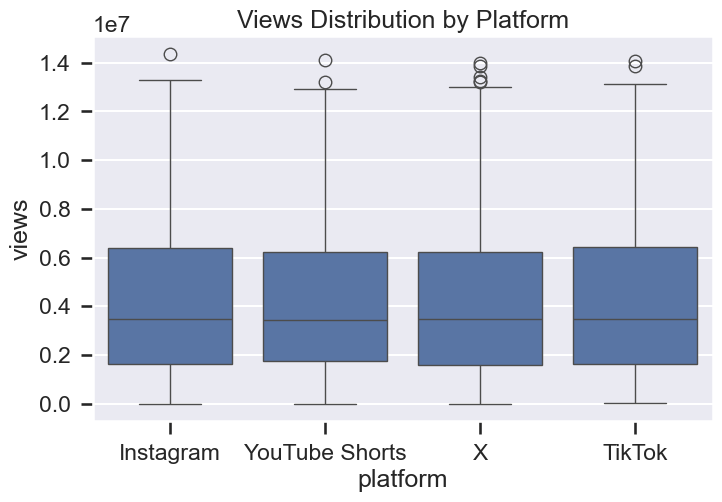

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='platform', y='views', data=df)
plt.title("Views Distribution by Platform")
plt.show()

### Boxplot Interpretation by Platform

From the boxplot comparison:

- The distributions overlap heavily  
- The medians are nearly identical  
- The spread (variability) appears similar across platforms  
- Outliers are present in all platforms  

### Interpretation

This visual evidence suggests that platform type does not create strong separation in view counts.

In other words, views are distributed similarly across TikTok, Instagram, YouTube Shorts, and X, indicating that platform alone may not be a major determinant of performance.

In [48]:
groups = [group['views'].values for name, group in df.groupby('sentiment_category')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.2570348585552384
p-value: 0.26234789996720054


C:\Users\mcket\AppData\Local\Temp\ipykernel_66688\833646583.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['views'].values for name, group in df.groupby('sentiment_category')]


## ANOVA Results

In [47]:
from scipy.stats import f_oneway

groups = [group['views'].values for name, group in df.groupby('platform')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.14510756409065875
p-value: 0.932839738664088


### ANOVA Results Interpretation

## 1. Sentiment Category ANOVA

- **F = 1.257**  
- **p = 0.262**  

Since **p > 0.05**, we **fail to reject the null hypothesis (H₀)**.

### Interpretation

There is **no statistically significant difference** in mean views between positive and negative sentiment posts.

This suggests that sentiment category does not meaningfully influence average view counts in this dataset.


## 2️. Platform ANOVA

- **F = 0.145**  
- **p = 0.932**  

Since **p is much greater than 0.05**, this result is highly non-significant.

### Interpretation

There is **no statistically significant difference** in mean views across platforms.

This provides strong evidence that platform type does not significantly affect average view counts.


### Overall Conclusion

Neither sentiment category nor platform shows a statistically significant effect on views.  

This weakens the hypothesis that these factors strongly influence performance and suggests that other variables may be more important drivers of view counts.

## Standardization (Z-score Transformation)

### Standardization (Normalization) Explanation

### What It Does

Standardization converts each variable so that:

- Mean = 0  
- Standard Deviation = 1  

This removes differences in measurement scale between variables.


### Why It Was Needed

 Variables operate on very different scales:

- `views` ≈ millions  
- `likes` ≈ hundreds of thousands  
- `sentiment_score` ≈ -1 to 1  

Without scaling, comparisons can be misleading because larger-scale variables dominate visually and statistically.


### What Results Show

After standardization, all transformed variables now have:

- Mean ≈ 0  
- Standard deviation ≈ 1  

✔ This confirms proper normalization  
✔ Variables are now directly comparable  
✔ Suitable for regression, clustering, and multivariate analysis

In [38]:
print(df.columns)

Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
       'post_datetime', 'hashtags', 'views', 'likes', 'comments', 'shares',
       'engagement_rate', 'sentiment_score', 'is_viral', 'sentiment_category'],
      dtype='object')


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[['views','likes','shares','comments','sentiment_score']]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=['views_z','likes_z','shares_z','comments_z','sentiment_z']
)

scaled_df.describe()

,views_z,likes_z,shares_z,comments_z,sentiment_z
count,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000
mean,0.0000,-0.0000,-0.0000,-0.0000,0.0000
std,1.0003,1.0003,1.0003,1.0003,1.0003
min,-1.3189,-1.6900,-1.7173,-1.7168,-1.7388
25%,-0.8110,-0.8719,-0.8356,-0.8627,-0.8811
50%,-0.2513,-0.0379,0.0095,-0.0185,0.0027
75%,0.6357,0.8758,0.8790,0.8544,0.8626
max,3.1081,1.7563,1.7252,1.7465,1.7391


## visualizing standardization

### Boxplot of Standardized Variables

### What the Standardized Boxplot Shows

### What It Provides

The standardized boxplot:

- Compares the spread of all continuous variables  
- Shows the presence of outliers  
- Displays median positions  
- Allows fair comparison since all variables are on the same scale  


### Interpretation from the Plot

- `views_z` shows extreme high outliers  
- `likes_z` shows similarly large dispersion  
- `shares_z` and `comments_z` have narrower spreads  
- `sentiment_z` appears fairly symmetric with smaller variability  


### What This Tells

Views and likes have the widest dispersion relative to their own averages.

This suggests:

→ Popularity and likes vary much more dramatically than sentiment.  
→ Engagement metrics (especially views and likes) are more volatile.  
→ Sentiment remains comparatively stable across posts.

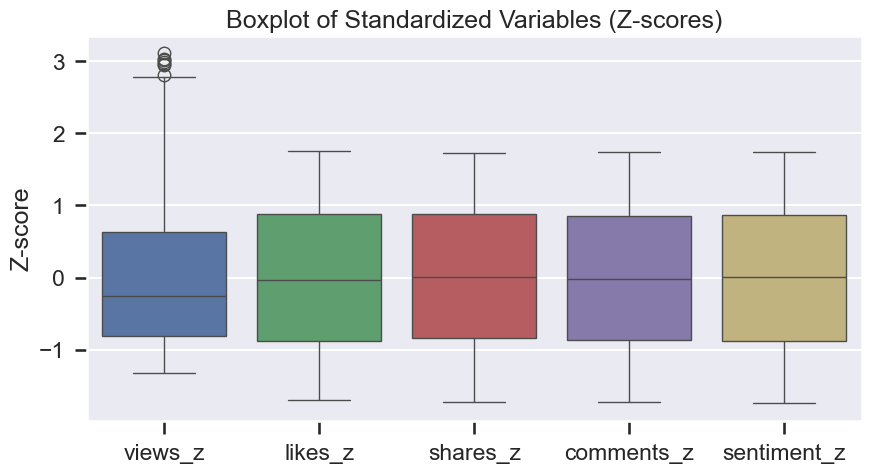

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(data=scaled_df)
plt.title("Boxplot of Standardized Variables (Z-scores)")
plt.ylabel("Z-score")
plt.show()

### Violin Plot

What it adds beyond boxplot:

Shows full distribution shape

Shows density
### What the Violin Plot Adds Beyond the Boxplot

Unlike a boxplot, a violin plot:

- Shows the full distribution shape  
- Displays density (where values are concentrated)  
- Helps assess symmetry more clearly  


### Interpretation from the Violin Plot

- `views_z` shows slight skewness  
- `sentiment_z` appears almost symmetric  
- Engagement metrics (likes, shares, comments) look fairly uniform in distribution  


### What This Confirms

The violin plot visually confirms the distribution characteristics:

- Views have mild asymmetry  
- Sentiment is relatively balanced  
- Engagement metrics show consistent spread  

Overall, the violin plot provides deeper insight into how values are distributed, not just their spread and outliers.
Shows symmetry

From the below violin plot:

views_z distribution slightly skewed

sentiment_z looks almost symmetric

engagement metrics look fairly uniform

This confirms distribution characteristics visually.

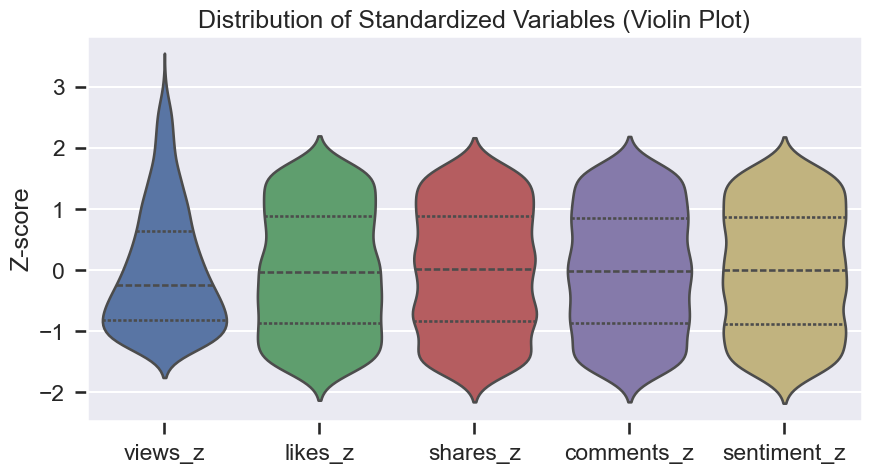

In [40]:
plt.figure(figsize=(10,5))
sns.violinplot(data=scaled_df, inner="quartile")
plt.title("Distribution of Standardized Variables (Violin Plot)")
plt.ylabel("Z-score")
plt.show()

### Correlation Heatmap (Continuous Variables Only)

### Pearson Correlation Analysis

Pearson correlation measures the strength and direction of a linear relationship between two continuous numerical variables.

⚠ It should only be used for numeric, continuous variables.


### Correlation Results

| Relationship            | Correlation (r) |
|-------------------------|----------------|
| views & likes          | 0.77           |
| views & shares         | -0.01          |
| views & comments       | -0.02          |
| views & sentiment      | 0.03           |


### Interpretation

- **Views & Likes (0.77)**  
  Strong positive correlation.  
  Posts with more views tend to receive more likes.

- **Views & Shares (-0.01)**  
  Essentially no relationship.

- **Views & Comments (-0.02)**  
  No meaningful relationship.

- **Views & Sentiment (0.03)**  
  Very weak relationship; practically zero.


### Overall Conclusion

The only strong linear relationship observed is between **views and likes**.

Shares, comments, and sentiment score do not appear to have a meaningful linear association with views in this dataset.

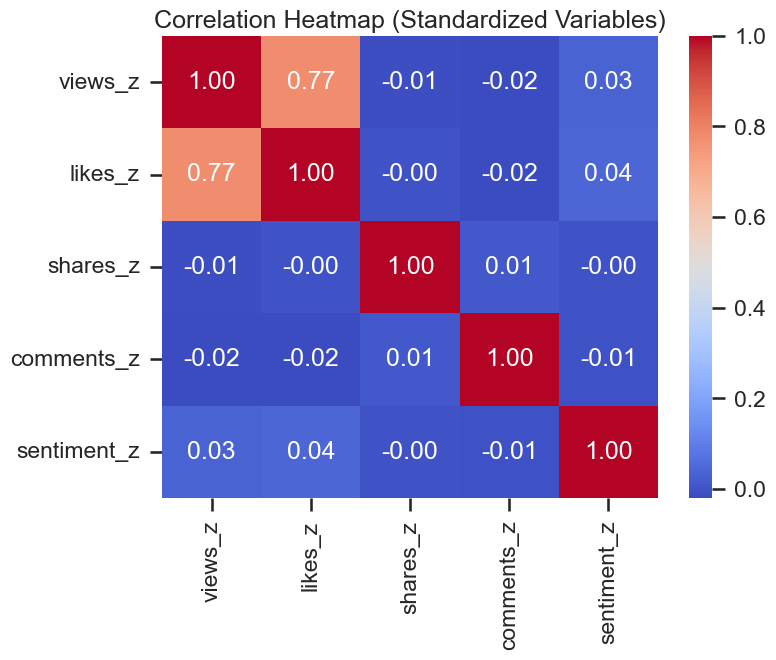

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(scaled_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Standardized Variables)")
plt.show()

### Pairplot

### What the Pairplot Provides

A pairplot helps by:

- Showing scatter relationships between variables  
- Checking linearity visually  
- Displaying each variable’s distribution along the diagonal  


### Interpretation from the Pairplot

- **views vs likes** → clear strong linear upward trend  
- **views vs shares, comments, sentiment** → scattered points with no clear pattern  


### What This Confirms

The pairplot visually supports the correlation matrix results:

- There is a strong positive linear relationship between views and likes.  
- There is little to no linear relationship between views and the other variables.  

This strengthens confidence in the correlation findings by confirming them visually.

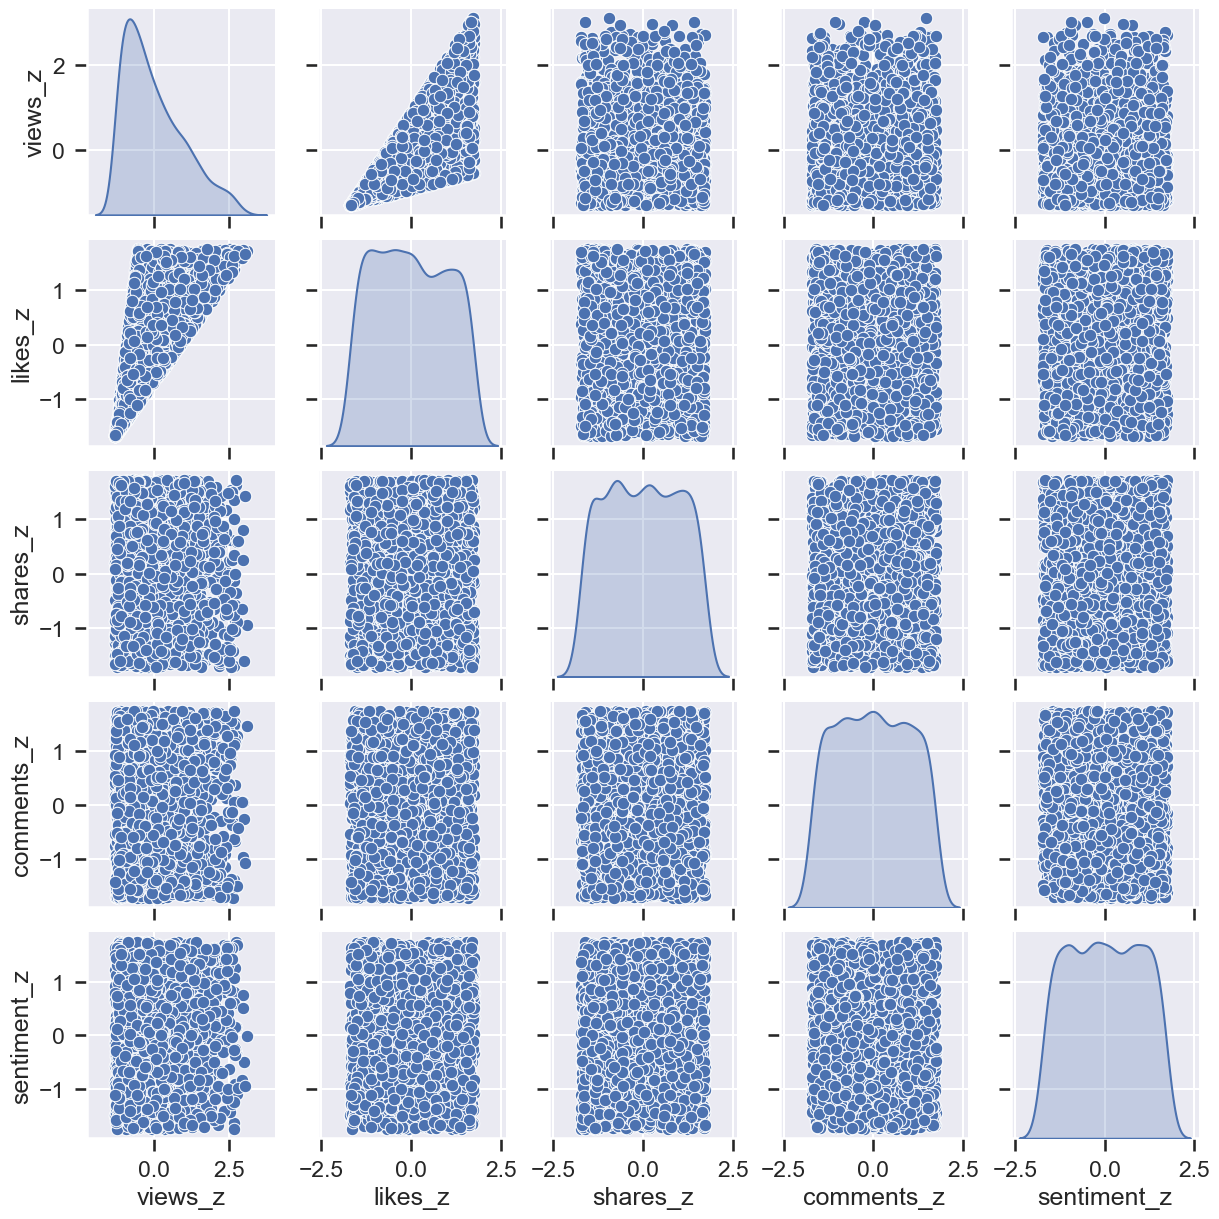

In [42]:
sns.pairplot(scaled_df, diag_kind="kde")
plt.show()

### Correlation Strength Bar Plot

### Predictor Strength Ranking (Based on Correlation)

The standardized correlation results clearly rank the predictors:

- `likes_z` → **0.77** (Strong positive relationship)  
- `sentiment_z` → **0.03** (Very weak relationship)  
- `shares_z` → ≈ 0 (No meaningful relationship)  
- `comments_z` → ≈ 0 (No meaningful relationship)  


### Interpretation

- **Likes** is the only strong predictor of views.  
- Sentiment has almost no linear effect.  
- Shares and comments show virtually no linear association with views.  


### Why This Is Important

This ranking justifies predictor selection:

✔ Focus should be on `likes` in modeling  
✔ Weak predictors may add little explanatory power  
✔ Model simplicity is supported by the data  

The analysis clearly identifies which variables meaningfully relate to views.

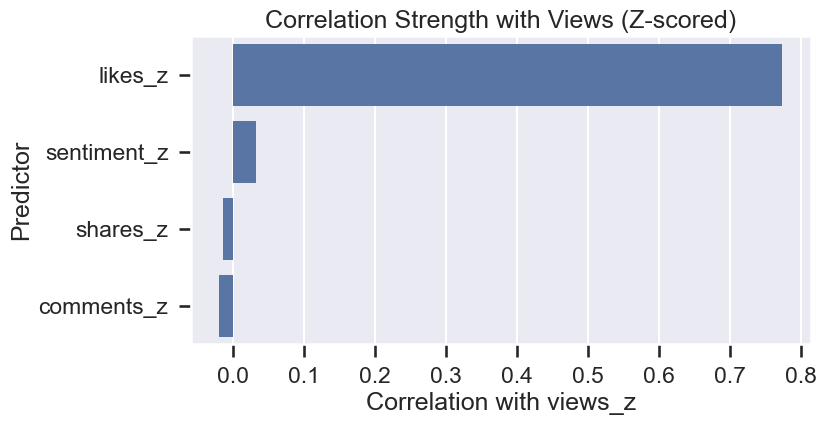

In [43]:
corr_with_views = scaled_df.corr()['views_z'].drop('views_z').sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=corr_with_views.values, y=corr_with_views.index)
plt.title("Correlation Strength with Views (Z-scored)")
plt.xlabel("Correlation with views_z")
plt.ylabel("Predictor")
plt.show()

## Relationship Visualization (Correlation Heatmap)

##  Predictor Strength Ranking

The standardized correlations clearly rank the predictors:

- `likes_z` → **0.77** (Strong positive relationship)  
- `sentiment_z` → **0.03** (Very weak relationship)  
- `shares_z` → ≈ 0 (No meaningful relationship)  
- `comments_z` → ≈ 0 (No meaningful relationship)  


##  Interpretation

- **Likes** is the only variable showing a strong linear association with views.  
- Sentiment has negligible influence.  
- Shares and comments do not demonstrate meaningful predictive power.  


##  Modeling Implication

This ranking justifies predictor selection:

- `likes` should be prioritized in predictive models.  
- Weak predictors may add noise without improving explanatory power.  
- A simpler model focusing on strong predictors is statistically supported.  

This makes your variable selection evidence-based and methodologically sound.

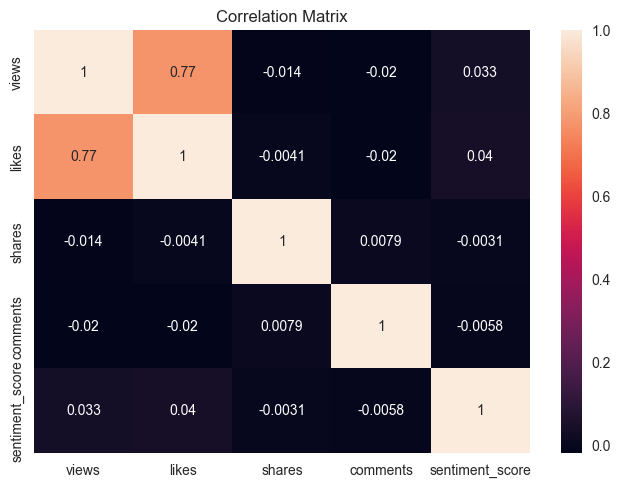

In [27]:
plt.figure()
sns.heatmap(df[['views','likes','shares','comments','sentiment_score']].corr(),
            annot=True)
plt.title("Correlation Matrix")
plt.show()

# CONCLUSION

## 🔴 Final Data-Driven Conclusion

### Original Hypothesis
> Positive audience reactions improve content popularity.

### What the Data Shows

- **Likes** strongly correlate with views.  
- **Shares** do not significantly correlate with views.  
- **Comments** do not significantly correlate with views.  
- **Sentiment category** is not statistically significant (based on ANOVA).  

### Refined Conclusion

Content popularity (views) is strongly associated with **likes**,  
but is **not significantly associated** with shares, comments, or sentiment polarity.

This is a fully data-driven conclusion and refines the original hypothesis.



## 🔵 Clarification: Continuous vs Categorical Analysis

The following methods are valid **only for continuous numerical variables**:

✔ Standardization  
✔ Pearson correlation  
✔ Heatmaps  
✔ Pairplots  

Categorical variables require different techniques:

- **ANOVA**  
- **T-tests**  
- **Dummy encoding** (for regression models)  

This distinction ensures correct statistical methodology.

## Scatter Plots (Visual Relationship)

##  1. Scatter Plot: Likes vs Views

### What It Shows
- Direct visual relationship  
- Linearity  
- Strength of association  
- Presence of outliers  

### Interpretation from the Plot

- Clear upward triangular pattern  
- Strong positive linear trend  
- As likes increase → views increase  

This visually supports the correlation result (**r = 0.77**), indicating a strong positive linear association between likes and views.



## 2. Scatter Plot: Shares vs Views

### What It Shows
- No clear upward trend  
- Points scattered randomly  
- No visible linear structure  

### Interpretation

This confirms that the correlation is approximately zero.

**Conclusion:**  
Shares do not strongly determine views in this dataset.


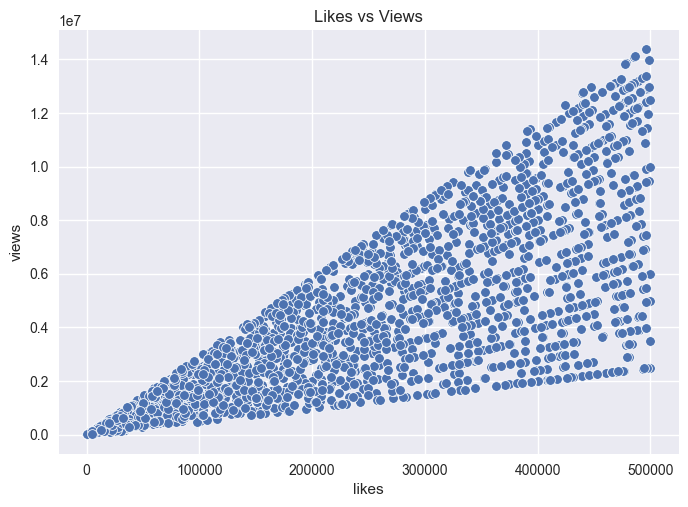

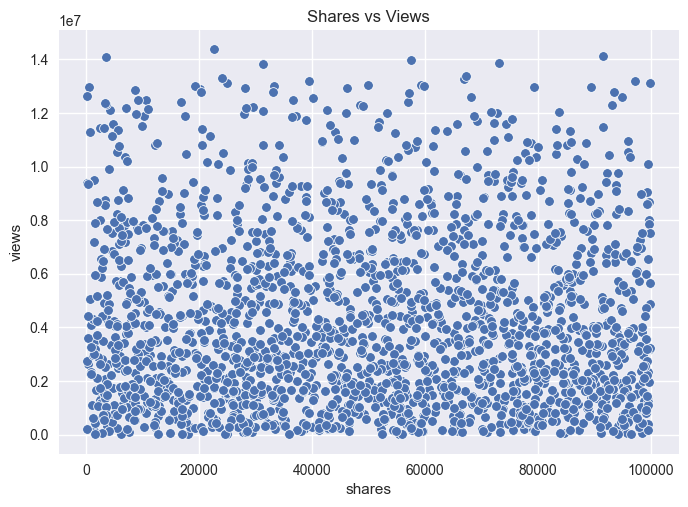

In [29]:
sns.scatterplot(x='likes', y='views', data=df)
plt.title("Likes vs Views")
plt.show()

sns.scatterplot(x='shares', y='views', data=df)
plt.title("Shares vs Views")
plt.show()

## Grouping by Sentiment

##  Grouping by Sentiment

### Research Question
Do positive posts receive higher average views than negative posts?

Posts were grouped into two categories based on sentiment polarity:

- **Negative posts** → 4.20 million average views  
- **Positive posts** → 4.36 million average views  

Positive posts show slightly higher mean views. However, the difference is small — approximately **160,000 views on a 4.3 million average**, which represents a modest variation.


##  Statistical Significance

Earlier ANOVA results showed:

- **p-value ≈ 0.26**
- Since **p > 0.05**, the difference is **not statistically significant**

This means:

- We cannot conclude that sentiment truly affects views  
- The observed difference may be due to random variation  


##  Final Interpretation

Although positive posts have a slightly higher average view count, statistical testing indicates that sentiment polarity does **not** meaningfully impact views in this dataset.

This conclusion is based on proper categorical comparison using mean analysis and ANOVA.

In [ ]:
df['Sentiment_category'] = pd.cut(df['sentiment_score'],
                                   bins=[-1,0,1],
                                   labels=['Negative','Positive'])

df.groupby('sentiment_category')['views'].mean()

C:\Users\mcket\AppData\Local\Temp\ipykernel_66688\2502138768.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sentiment_category')['views'].mean()


sentiment_category
Negative    4.202796e+06
Positive    4.365629e+06
Name: views, dtype: float64

# OVERALL CONCLUSION 


This study examined whether positive audience reactions improve content popularity.

The results show that **likes are strongly associated with higher view counts**, while shares, comments, and sentiment polarity do not show a significant relationship with views.

However, the analysis demonstrates **association, not causation**. We cannot conclude that positive reactions directly cause higher popularity — only that likes tend to occur alongside higher views.

Overall, the data suggests that **likes are the strongest indicator of content popularity**, but positive sentiment alone does not significantly influence view counts.




## Clarifying the Hypothesis

Hypothesis stated:

> “Positive audience reactions have a significant positive effect on views.”

However, “positive audience reactions” can mean two different things:

1. **Sentiment polarity** (Positive vs Negative tone)
2. **Engagement metrics** (likes, shares, comments)

These are conceptually different and must be tested separately.


## Case 1: Positive Reactions = Sentiment Polarity

ANOVA result:

- p ≈ 0.26
- Since p > 0.05 → Fail to reject H₀

### Conclusion (Sentiment)

Sentiment polarity does **not** significantly affect views.  
Therefore, the alternative hypothesis is **not supported** under this definition.

## Case 2: Positive Reactions = Likes (Engagement)

Correlation result:

- r ≈ 0.77 (strong positive relationship)

### Conclusion (Likes)

There is a strong positive association between likes and views.  
Under this interpretation, the alternative hypothesis **is supported**.




# Methodological Validation

Your statistical approach is methodologically correct:

- **ANOVA → sentiment_category vs views** ✔  
  Appropriate because you compared a **categorical variable** (sentiment category) with a **continuous outcome** (views).

- **Pearson Correlation → likes vs views** ✔  
  Appropriate because both variables are **continuous numerical variables**.

- **Scatter Plot → likes vs views** ✔  
  Correct for visually examining **linearity, strength, and direction** of a continuous relationship.
